## Replicate Figure 3a

In [ ]:
from modules import RSCGenerator, SCMSimulator, RandomSeeding


/tmp/ipykernel_24468/1016605253.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right', framealpha=1, edgecolor='black')


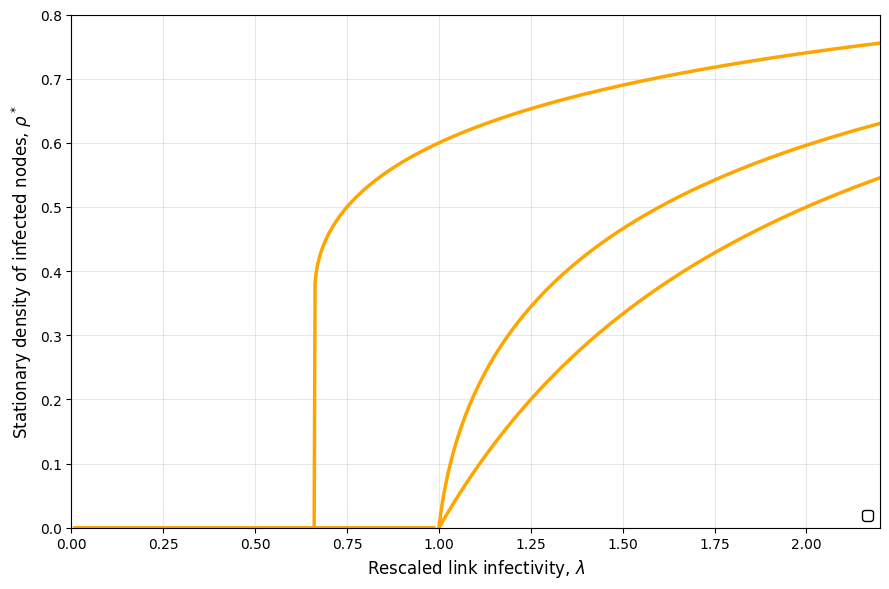

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Analytical Curves
def mf_rho(lam, lam_d):
    """
    Calculates the mean-field analytical steady states of the SCM
    p = (lam_d - lam +- sqrt((lam - lam_d)^2 -4lam_d(1-lam))) / (2lam_d)
    """
    if lam_d == 0:
        return 1 - 1 / lam

    discriminant = (lam - lam_d)**2 - 4 * lam_d * (1 - lam)
    sqrt_term = np.sqrt(discriminant.astype(complex))
    rho = (lam_d - lam + sqrt_term) / (2 * lam_d)
    rho = np.where(np.imag(rho) != 0, 0, rho)
            
    return rho.real

lambdas = np.linspace(0.01, 2.5, 1000)
rho_0 = mf_rho(lambdas, 0.0)
rho_08 = mf_rho(lambdas, 0.8)
rho_25 = mf_rho(lambdas, 2.5)

# Plot
plt.figure(figsize=(9, 6))
plt.plot(lambdas, rho_0, color='orange', lw=2.5)
plt.plot(lambdas, rho_08, color='orange', lw=2.5)
plt.plot(lambdas, rho_25, color='orange', lw=2.5)

plt.xlim(0, 2.2)
plt.ylim(0, 0.8)
plt.xlabel(r'Rescaled link infectivity, $\lambda$', fontsize=12)
plt.ylabel(r'Stationary density of infected nodes, $\rho^*$', fontsize=12)
plt.legend(loc='lower right', framealpha=1, edgecolor='black')
plt.grid(alpha=0.3)
plt.tight_layout()

# Save the plot
plt.savefig('analytical_curves.png', dpi=300)
plt.show()